In [1]:
# members_v3.csv 컬럼 설명
# msno                    : 유저 고유 ID (해시 문자열, Primary Key)
# city                    : 유저 거주 도시 코드 (범주형 정수, 21종, 실제 도시명은 비공개)
# bd                      : 유저 나이(age). 자기기입 값이라 이상치 많음 (0, 음수, 비현실적으로 큰 값 등)
# gender                  : 성별 ('male', 'female', 결측 다수)
# registered_via          : 가입 경로/채널 코드 (범주형 정수, 18종)
# registration_init_time  : 가입일 (YYYYMMDD 형식의 정수)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# 시각화 스타일
sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams.update({
    "figure.dpi": 110,
    "font.family": "Malgun Gothic",
    "axes.unicode_minus": False,
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "axes.titlecolor": "#0b0b0b",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "grid.color": "#e1e0d9",
    "text.color": "#0b0b0b",
})

SERIES_1 = "#2a78d6"
CUTOFF_DATE = pd.Timestamp("2017-01-31")
pd.set_option("display.max_columns", None)

In [3]:
RAW_DIR = Path("../data/raw").resolve()
df = pd.read_csv(RAW_DIR / "members_v3.csv")

print(df.shape)
print(df.dtypes)
df.head()

(6769473, 6)
msno                        str
city                      int64
bd                        int64
gender                      str
registered_via            int64
registration_init_time    int64
dtype: object


,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915


In [4]:
print(f"메모리 사용량: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"전체 행 수: {len(df):,}")
print(f"msno 고유값 수: {df['msno'].nunique():,}")
print(f"msno 중복 존재 여부: {df['msno'].duplicated().any()}")

메모리 사용량: 605.9 MB
전체 행 수: 6,769,473
msno 고유값 수: 6,769,473
msno 중복 존재 여부: False


In [5]:
missing = df.isna().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
missing

,missing_count,missing_pct
msno,0,0.00
city,0,0.00
bd,0,0.00
gender,4429505,65.43
registered_via,0,0.00
registration_init_time,0,0.00


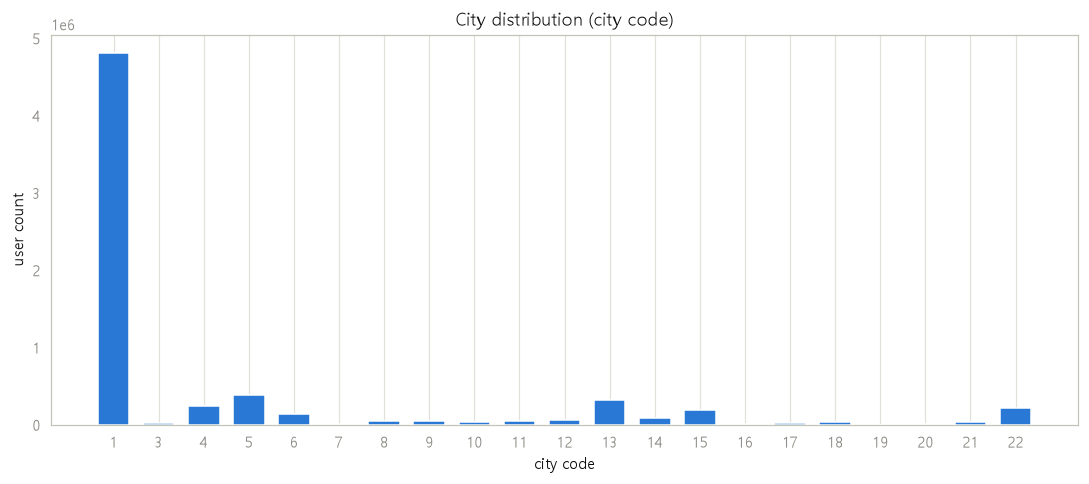

city
1     4804326
3       27282
4      246848
5      385069
6      135200
7       11610
8       45975
9       47639
10      32482
11      47489
12      66843
13     320978
14      89940
15     190213
16       5092
17      27772
18      38039
19       1199
20       4233
21      30837
22     210407
Name: count, dtype: int64

In [6]:
city_counts = df["city"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(city_counts.index.astype(str), city_counts.values, color=SERIES_1, width=0.7)
ax.set_xlabel("city code")
ax.set_ylabel("user count")
ax.set_title("City distribution (city code)")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

city_counts

In [7]:
print(df["bd"].describe())
print()
print(f"bd <= 0 (미기입/기본값 추정): {(df['bd'] <= 0).sum():,} ({(df['bd'] <= 0).mean()*100:.1f}%)")
print(f"bd < 0 (음수 이상치): {(df['bd'] < 0).sum():,}")
print(f"bd > 100 (비현실적 이상치): {(df['bd'] > 100).sum():,} ({(df['bd'] > 100).mean()*100:.2f}%)")

count    6.769473e+06
mean     9.795794e+00
std      1.792590e+01
min     -7.168000e+03
25%      0.000000e+00
50%      0.000000e+00
75%      2.100000e+01
max      2.016000e+03
Name: bd, dtype: float64

bd <= 0 (미기입/기본값 추정): 4,540,489 (67.1%)
bd < 0 (음수 이상치): 274
bd > 100 (비현실적 이상치): 5,377 (0.08%)


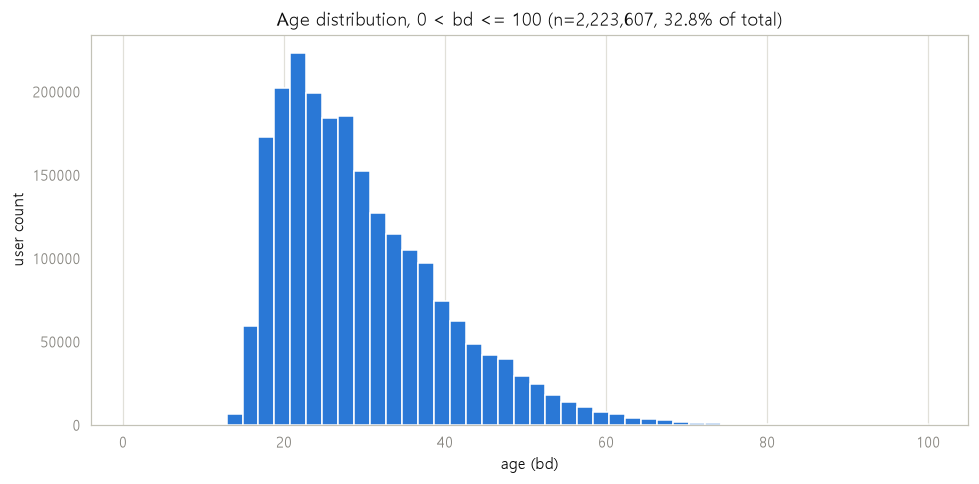

In [8]:
plausible_bd = df.loc[(df["bd"] > 0) & (df["bd"] <= 100), "bd"]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(plausible_bd, bins=50, color=SERIES_1)
ax.set_xlabel("age (bd)")
ax.set_ylabel("user count")
ax.set_title(f"Age distribution, 0 < bd <= 100 (n={len(plausible_bd):,}, {len(plausible_bd)/len(df)*100:.1f}% of total)")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

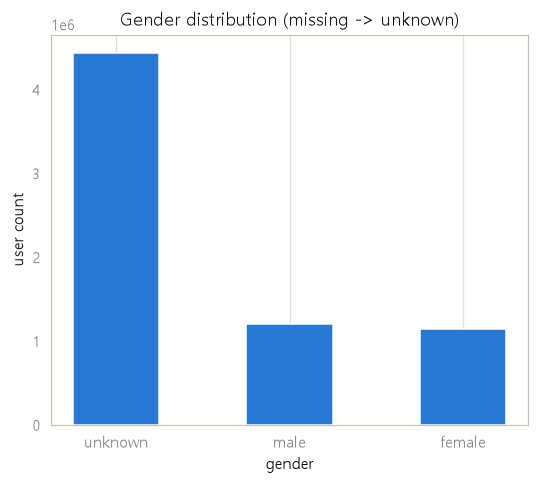

gender
unknown    4429505
male       1195355
female     1144613
Name: count, dtype: int64

In [9]:
gender_counts = df["gender"].fillna("unknown").value_counts()

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.bar(gender_counts.index, gender_counts.values, color=SERIES_1, width=0.5)
ax.set_xlabel("gender")
ax.set_ylabel("user count")
ax.set_title("Gender distribution (missing -> unknown)")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

gender_counts

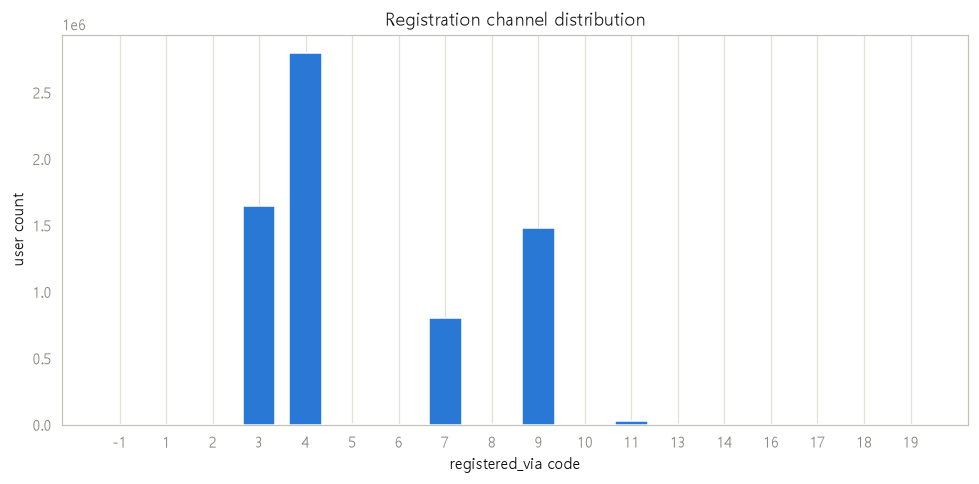

registered_via
-1           1
 1          43
 2        1452
 3     1643208
 4     2793213
 5        3115
 6        1213
 7      805895
 8        3982
 9     1482863
 10         10
 11      25047
 13       5455
 14        615
 16        888
 17       1494
 18          5
 19        974
Name: count, dtype: int64

In [10]:
via_counts = df["registered_via"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(via_counts.index.astype(str), via_counts.values, color=SERIES_1, width=0.7)
ax.set_xlabel("registered_via code")
ax.set_ylabel("user count")
ax.set_title("Registration channel distribution")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

via_counts

관측 종료일(2017-01-31) 이후 가입 기록: 317,963건


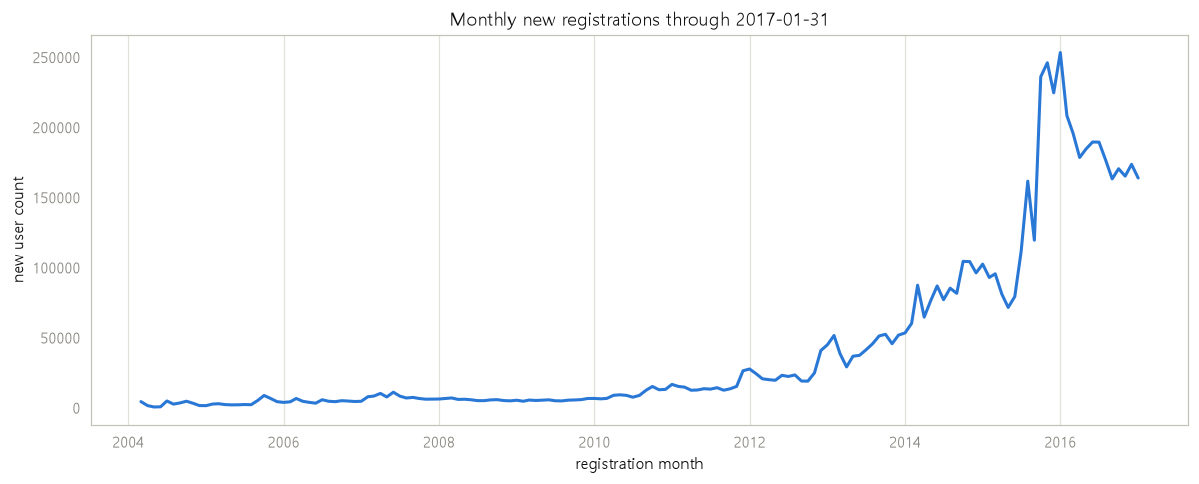

In [11]:
df["registration_date"] = pd.to_datetime(df["registration_init_time"], format="%Y%m%d")
post_cutoff_count = (df["registration_date"] > CUTOFF_DATE).sum()
print(f"관측 종료일({CUTOFF_DATE.date()}) 이후 가입 기록: {post_cutoff_count:,}건")

# 모델 피처 관측 시점에 존재했던 가입 기록만 시계열 분포에 사용
observed_reg = df.loc[df["registration_date"] <= CUTOFF_DATE].copy()
observed_reg["registration_month"] = observed_reg["registration_date"].dt.to_period("M")
monthly_reg = observed_reg.groupby("registration_month").size()

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(monthly_reg.index.to_timestamp(), monthly_reg.values, color=SERIES_1, linewidth=2)
ax.set_xlabel("registration month")
ax.set_ylabel("new user count")
ax.set_title(f"Monthly new registrations through {CUTOFF_DATE.date()}")
ax.grid(axis="y")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [12]:
# ------------------------------------------------------------------
# 데이터 품질 이슈 요약 (전처리 단계에서 처리 필요)
# 1. bd(나이): 절반 이상이 0 이하(미기입 추정), 음수와 비현실적으로 큰 값이 존재
#    -> 전처리에서는 유효 범위 1~100 밖의 값을 결측으로 마스킹하고 결측 여부 피처를 추가한다.
# 2. gender: 결측 비율이 매우 높음 (미기입 사용자 다수) -> 'unknown' 카테고리로 별도 처리 고려
# 3. city, registered_via: 실제 의미가 비공개된 범주형 코드값 -> 원핫 등으로 처리 필요, city=1이 결측/미상 버킷일 가능성
# 4. registration_init_time: 가입 경과일수는 피처 관측 종료일 2017-01-31을 기준으로 계산한다.
#    원본 members_v3에는 관측 종료일 이후 가입자도 포함되므로 시계열 해석 시 구분해야 한다.
# ------------------------------------------------------------------
print("데이터 품질 이슈 요약 완료 (위 주석 참고)")

데이터 품질 이슈 요약 완료 (위 주석 참고)
